# 🎭 EDA — Masked Face Super Resolution (Kaggle: splitted-masked-ffhq-cropped)

Analyse exploratoire **exhaustive** du dataset utilisé pour le projet de reconstruction/super-résolution de visages masqués.

## Plan
1. **Configuration & chargement**
2. **Structure & arborescence**
3. **Volumétrie** — combien d'images par part/split/catégorie
4. **Appariement masked ↔ unmasked** *(critique pour l'entraînement)*
5. **Propriétés des images** — dimensions, modes, tailles de fichier
6. **Visualisation de paires** — qualité & alignement
7. **Échantillons par part** — diversité visuelle
8. **Statistiques pixel** — moyennes/écarts-types par canal
9. **Histogrammes** — distribution des intensités
10. **Image moyenne & localisation du masque**
11. **Comparaison inter-parts** — homogénéité des données
12. **Synthèse & recommandations**

## 1. Configuration & chargement

In [1]:
import os
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 90
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [2]:
# ⚠️ CHANGE THIS PATH to where you extracted the Kaggle dataset
# Structure attendue : DATA_DIR / {part1,part2,part3} / {train,val,test} / {masked,unmasked} / *.png
DATA_DIR = Path('../dataset/')

PARTS = ['part1', 'part2', 'part3']
SPLITS = ['train', 'val', 'test']
CATEGORIES = ['masked', 'unmasked']

assert DATA_DIR.is_dir(), f"❌ DATA_DIR introuvable: {DATA_DIR.resolve()}\n→ Ajuste la variable DATA_DIR ci-dessus."
print(f"✓ Data dir: {DATA_DIR.resolve()}")

✓ Data dir: C:\Users\khalid\Desktop\Masked-_Face_Projet\dataset


## 2. Structure & arborescence

Vérification que la structure correspond à l'attendu : `part{1,2,3} / {train,val,test} / {masked,unmasked}`.

In [3]:
print(f"{DATA_DIR.name}/")
for part_dir in sorted(DATA_DIR.iterdir()):
    if not part_dir.is_dir() or part_dir.name not in PARTS:
        continue
    print(f"├── {part_dir.name}/")
    splits = sorted([d for d in part_dir.iterdir() if d.is_dir()])
    for i, split_dir in enumerate(splits):
        marker = '└──' if i == len(splits)-1 else '├──'
        print(f"│   {marker} {split_dir.name}/")
        for cat_dir in sorted(split_dir.iterdir()):
            if cat_dir.is_dir():
                n = len(list(cat_dir.glob('*.png')))
                print(f"│       ├── {cat_dir.name}/ ({n:,} images)")

dataset/
├── part1/
│   ├── test/
│       ├── masked/ (1,000 images)
│       ├── unmasked/ (1,000 images)
│   ├── train/
│       ├── masked/ (8,000 images)
│       ├── unmasked/ (8,000 images)
│   └── val/
│       ├── masked/ (1,000 images)
│       ├── unmasked/ (1,000 images)
├── part2/
│   ├── test/
│       ├── masked/ (1,000 images)
│       ├── unmasked/ (1,000 images)
│   ├── train/
│       ├── masked/ (8,000 images)
│       ├── unmasked/ (8,000 images)
│   └── val/
│       ├── masked/ (1,000 images)
│       ├── unmasked/ (1,000 images)
├── part3/
│   ├── test/
│       ├── masked/ (602 images)
│       ├── unmasked/ (602 images)
│   └── train/
│       ├── masked/ (4,813 images)
│       ├── unmasked/ (4,238 images)


## 3. Volumétrie

Comptage exact des images par combinaison (part, split, catégorie).

In [4]:
rows = []
for part in PARTS:
    for split in SPLITS:
        for cat in CATEGORIES:
            d = DATA_DIR / part / split / cat
            if d.is_dir():
                n = len(list(d.glob('*.png')))
                rows.append({'part': part, 'split': split, 'category': cat, 'count': n})

df_vol = pd.DataFrame(rows)
pivot = df_vol.pivot_table(index=['part','split'], columns='category', values='count', fill_value=0)
pivot['total'] = pivot.sum(axis=1)
pivot.loc[('TOTAL','')] = pivot.sum()
print(pivot.to_string())
print(f"\n🔢 TOTAL: {df_vol['count'].sum():,} images")

category     masked  unmasked    total    
part  split                               
part1 test  1000.00   1000.00  2000.00 NaN
      train 8000.00   8000.00 16000.00 NaN
      val   1000.00   1000.00  2000.00 NaN
part2 test  1000.00   1000.00  2000.00 NaN
      train 8000.00   8000.00 16000.00 NaN
      val   1000.00   1000.00  2000.00 NaN
part3 test   602.00    602.00  1204.00 NaN
      train 4813.00   4238.00  9051.00 NaN
TOTAL           NaN       NaN      NaN NaN

🔢 TOTAL: 50,255 images


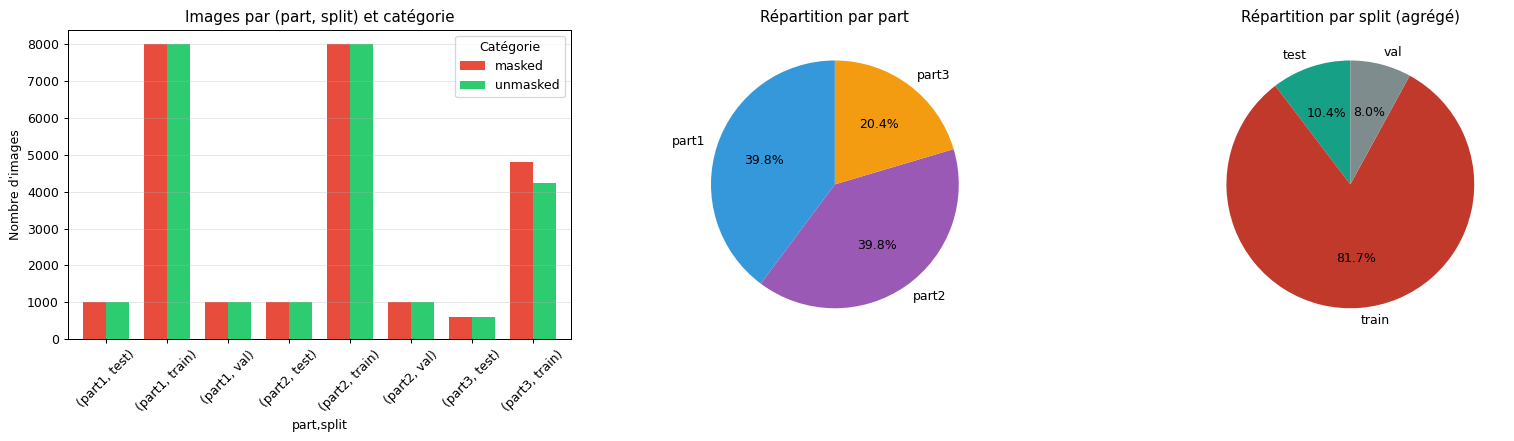

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart: counts per (part, split) stacked by category
pivot_plot = pivot.drop(index='TOTAL', errors='ignore')[['masked','unmasked']]
pivot_plot.plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'], width=0.75)
axes[0].set_title("Images par (part, split) et catégorie")
axes[0].set_ylabel('Nombre d\'images')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Catégorie')
axes[0].grid(axis='y', alpha=0.3)

# Pie: répartition par part
by_part = df_vol.groupby('part')['count'].sum()
axes[1].pie(by_part.values, labels=by_part.index, autopct='%1.1f%%',
            colors=['#3498db','#9b59b6','#f39c12'], startangle=90)
axes[1].set_title('Répartition par part')

# Pie: répartition par split (agrégé)
by_split = df_vol.groupby('split')['count'].sum()
axes[2].pie(by_split.values, labels=by_split.index, autopct='%1.1f%%',
            colors=['#16a085','#c0392b','#7f8c8d'], startangle=90)
axes[2].set_title('Répartition par split (agrégé)')

plt.tight_layout(); plt.show()

## 4. Appariement masked ↔ unmasked (CRITIQUE)

Pour l'entraînement supervisé, chaque image `masked/X.png` doit avoir son pendant `unmasked/X.png`.
Si ce n'est pas le cas → les paires ne sont pas alignées et il faut prévoir un filtre.

In [6]:
rows = []
for part in PARTS:
    for split in SPLITS:
        m_dir = DATA_DIR / part / split / 'masked'
        u_dir = DATA_DIR / part / split / 'unmasked'
        if not (m_dir.is_dir() and u_dir.is_dir()):
            continue
        m_files = {p.name for p in m_dir.glob('*.png')}
        u_files = {p.name for p in u_dir.glob('*.png')}
        common = m_files & u_files
        denom = max(len(m_files), len(u_files), 1)
        rows.append({
            'part': part, 'split': split,
            'masked': len(m_files), 'unmasked': len(u_files),
            'paired': len(common),
            'masked_only': len(m_files - u_files),
            'unmasked_only': len(u_files - m_files),
            'pair_rate_%': round(100 * len(common) / denom, 1),
        })

df_pair = pd.DataFrame(rows)
print(df_pair.to_string(index=False))
print(f"\n✓ Total paires utilisables: {df_pair['paired'].sum():,}")
print(f"⚠️  Images orphelines: {(df_pair['masked_only'].sum() + df_pair['unmasked_only'].sum()):,}")

 part split  masked  unmasked  paired  masked_only  unmasked_only  pair_rate_%
part1 train    8000      8000    8000            0              0       100.00
part1   val    1000      1000    1000            0              0       100.00
part1  test    1000      1000    1000            0              0       100.00
part2 train    8000      8000    8000            0              0       100.00
part2   val    1000      1000    1000            0              0       100.00
part2  test    1000      1000    1000            0              0       100.00
part3 train    4813      4238    4238          575              0        88.10
part3  test     602       602     602            0              0       100.00

✓ Total paires utilisables: 24,840
⚠️  Images orphelines: 575


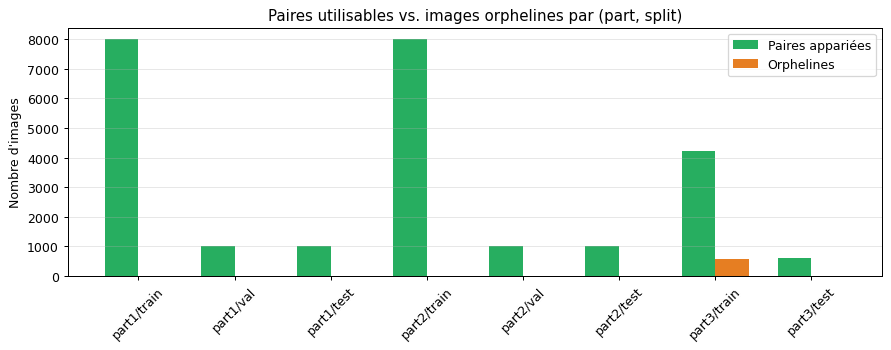

In [7]:
# Visualisation du taux d'appariement
fig, ax = plt.subplots(figsize=(10, 4))
labels = df_pair['part'] + '/' + df_pair['split']
x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, df_pair['paired'], width, label='Paires appariées', color='#27ae60')
ax.bar(x + width/2, df_pair['masked_only'] + df_pair['unmasked_only'], width,
       label='Orphelines', color='#e67e22')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45)
ax.set_ylabel('Nombre d\'images')
ax.set_title('Paires utilisables vs. images orphelines par (part, split)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Propriétés des images

Dimensions, modes couleur, tailles de fichier. On scanne **toutes** les images.

In [8]:
all_paths = list(DATA_DIR.glob('**/*.png'))
print(f"Scan de {len(all_paths):,} images...")

sizes = Counter()
modes = Counter()
file_sizes_kb = []

for p in all_paths:
    with Image.open(p) as im:
        sizes[im.size] += 1
        modes[im.mode] += 1
    file_sizes_kb.append(p.stat().st_size / 1024)

print(f"\n📐 Dimensions trouvées : {dict(sizes)}")
print(f"🎨 Modes couleur      : {dict(modes)}")
print(f"\n💾 Taille fichier (KB) : min={min(file_sizes_kb):.1f}  max={max(file_sizes_kb):.1f}  "
      f"mean={np.mean(file_sizes_kb):.1f}  median={np.median(file_sizes_kb):.1f}")

Scan de 50,335 images...

📐 Dimensions trouvées : {(128, 128): 50335}
🎨 Modes couleur      : {'RGB': 50335}

💾 Taille fichier (KB) : min=8.7  max=37.4  mean=27.7  median=27.9


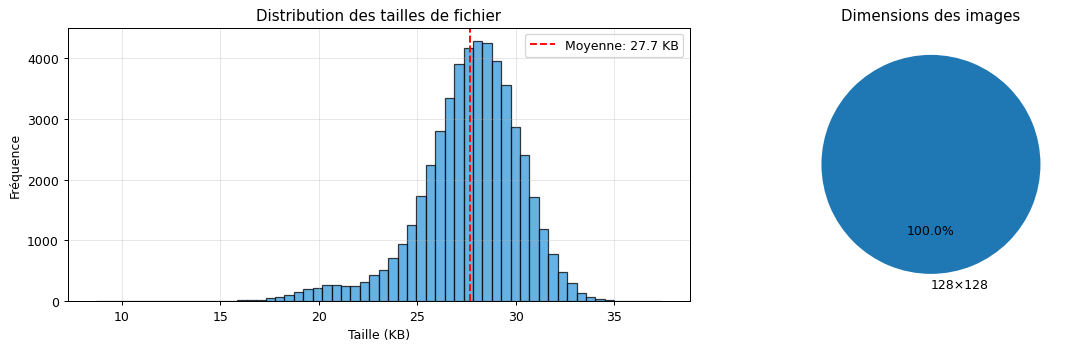

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(file_sizes_kb, bins=60, color='#3498db', edgecolor='black', alpha=0.75)
axes[0].axvline(np.mean(file_sizes_kb), color='red', linestyle='--', label=f'Moyenne: {np.mean(file_sizes_kb):.1f} KB')
axes[0].set_xlabel('Taille (KB)'); axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution des tailles de fichier')
axes[0].legend(); axes[0].grid(alpha=0.3)

top_sizes = dict(sizes.most_common(6))
axes[1].pie(top_sizes.values(), labels=[f"{k[0]}×{k[1]}" for k in top_sizes],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Dimensions des images')
plt.tight_layout(); plt.show()

## 6. Visualisation de paires appariées

Affichage de quelques paires `masked`/`unmasked` ayant le **même filename**. Ça permet de voir si les paires correspondent visuellement (même personne ? même pose ?).

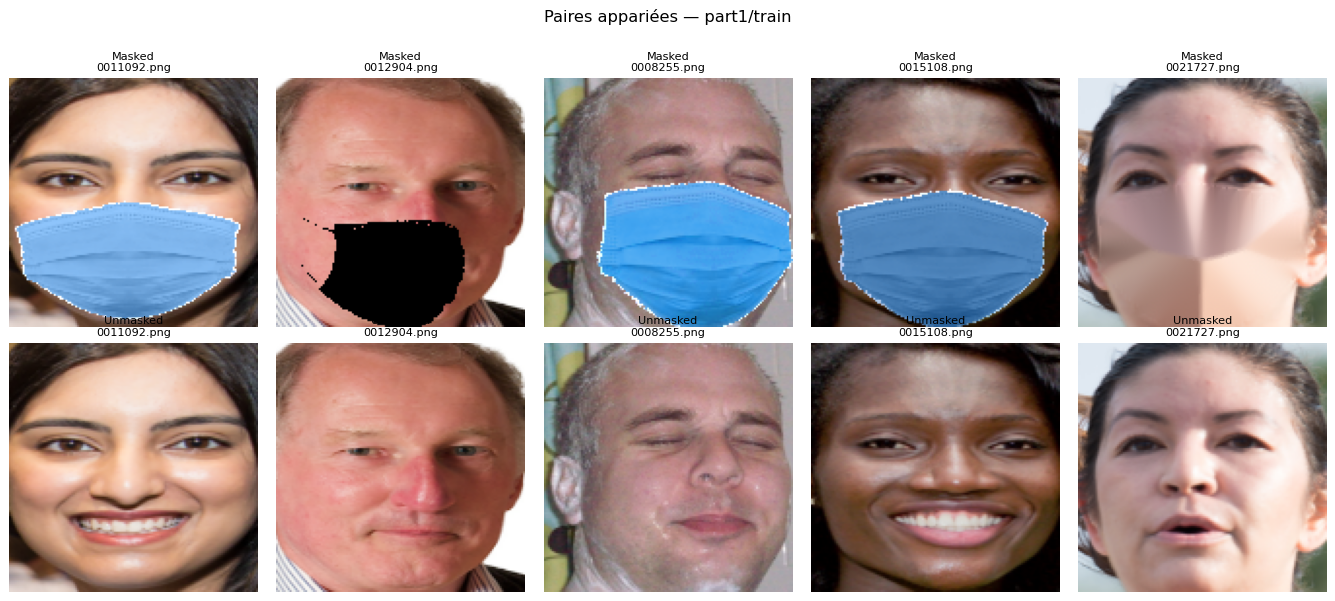

In [10]:
def get_paired_samples(part, split, n=5):
    m_dir = DATA_DIR / part / split / 'masked'
    u_dir = DATA_DIR / part / split / 'unmasked'
    if not (m_dir.is_dir() and u_dir.is_dir()):
        return []
    m_files = {p.name for p in m_dir.glob('*.png')}
    u_files = {p.name for p in u_dir.glob('*.png')}
    common = sorted(m_files & u_files)
    if not common:
        return []
    sample = np.random.choice(common, size=min(n, len(common)), replace=False)
    return [(m_dir/name, u_dir/name) for name in sample]

pairs = get_paired_samples('part1', 'train', n=5)

if pairs:
    fig, axes = plt.subplots(2, len(pairs), figsize=(3*len(pairs), 6.5))
    if len(pairs) == 1: axes = axes.reshape(2, 1)
    for i, (m_path, u_path) in enumerate(pairs):
        axes[0,i].imshow(Image.open(m_path)); axes[0,i].axis('off')
        axes[0,i].set_title(f'Masked\n{m_path.name}', fontsize=9)
        axes[1,i].imshow(Image.open(u_path)); axes[1,i].axis('off')
        axes[1,i].set_title(f'Unmasked\n{u_path.name}', fontsize=9)
    plt.suptitle('Paires appariées — part1/train', fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()
else:
    print("⚠️ Aucune paire appariée trouvée dans part1/train.")
    print("    → Le pairing par filename n'est pas effectif ici.")
    print("    → Option : traiter comme dataset non-apparié (CycleGAN-style) OU générer des masques synthétiquement.")

## 7. Échantillons aléatoires par part

Les 3 parts viennent de sources légèrement différentes — vérifions qu'elles sont visuellement cohérentes.

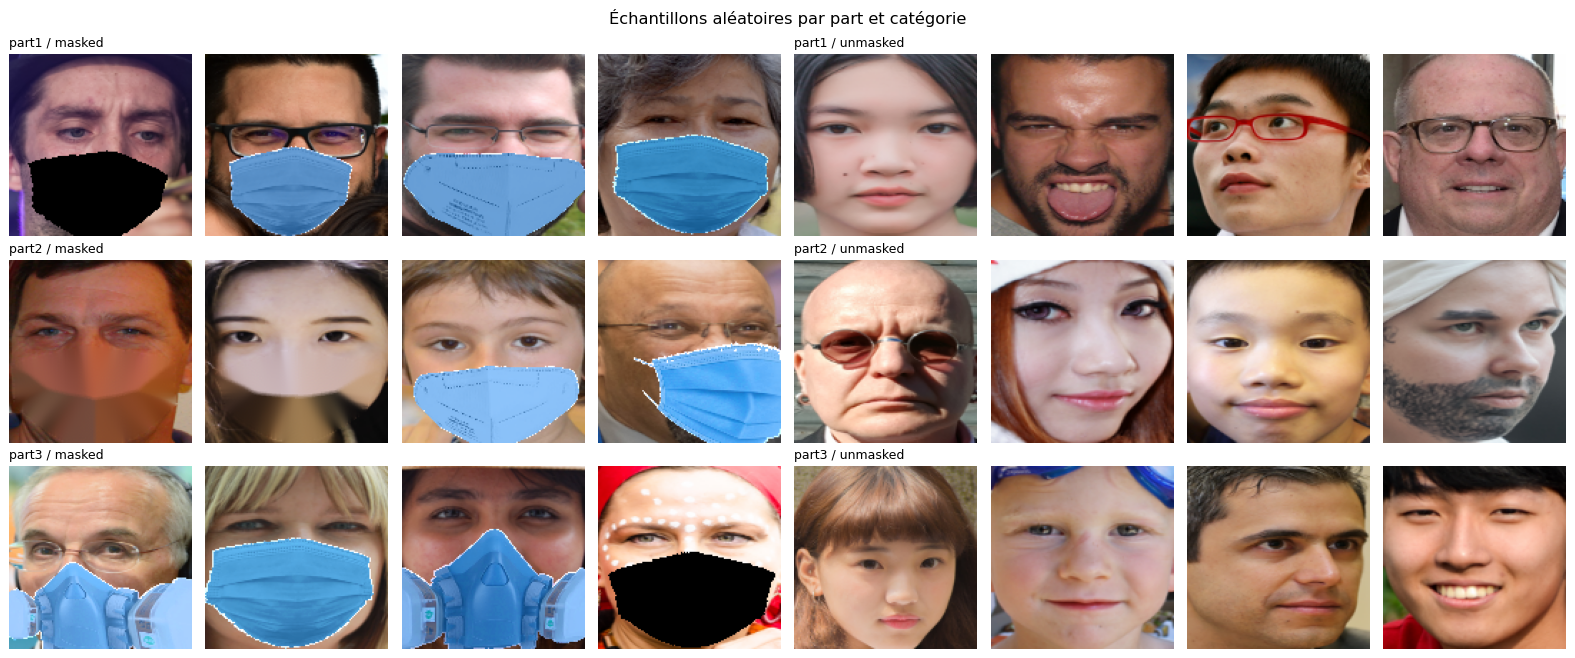

In [11]:
n_per_cat = 4
fig, axes = plt.subplots(len(PARTS), n_per_cat*2, figsize=(2.2*n_per_cat*2, 2.5*len(PARTS)))

for i, part in enumerate(PARTS):
    for j, cat in enumerate(CATEGORIES):
        # trouver un split existant
        d = None
        for split in SPLITS:
            candidate = DATA_DIR / part / split / cat
            if candidate.is_dir() and any(candidate.glob('*.png')):
                d = candidate; break
        if d is None: continue
        files = list(d.glob('*.png'))
        sample = np.random.choice(files, size=min(n_per_cat, len(files)), replace=False)
        for k, p in enumerate(sample):
            ax = axes[i, j*n_per_cat + k]
            ax.imshow(Image.open(p)); ax.axis('off')
            if k == 0: ax.set_title(f'{part} / {cat}', fontsize=10, loc='left')

plt.suptitle('Échantillons aléatoires par part et catégorie', fontsize=13)
plt.tight_layout(); plt.show()

## 8. Statistiques pixel par catégorie

Moyenne et écart-type par canal RGB. Utile pour définir les valeurs de normalisation du pipeline PyTorch.

In [12]:
def compute_pixel_stats(part, split, cat, max_samples=1000):
    d = DATA_DIR / part / split / cat
    if not d.is_dir(): return None
    files = list(d.glob('*.png'))
    if not files: return None
    if len(files) > max_samples:
        idx = np.random.choice(len(files), size=max_samples, replace=False)
        files = [files[i] for i in idx]
    # streaming pour éviter d'exploser la RAM
    sum_, sum_sq, n_px = np.zeros(3), np.zeros(3), 0
    for f in files:
        arr = np.array(Image.open(f).convert('RGB')).astype(np.float64)
        sum_   += arr.sum(axis=(0,1))
        sum_sq += (arr**2).sum(axis=(0,1))
        n_px   += arr.shape[0] * arr.shape[1]
    mean = sum_ / n_px
    var  = sum_sq / n_px - mean**2
    std  = np.sqrt(np.maximum(var, 0))
    return {'n_images': len(files), 'mean': mean, 'std': std}

stats_rows = []
for part in PARTS:
    for cat in CATEGORIES:
        s = compute_pixel_stats(part, 'train', cat, max_samples=1000)
        if s is None: continue
        stats_rows.append({
            'part': part, 'category': cat, 'n': s['n_images'],
            'mean_R': s['mean'][0], 'mean_G': s['mean'][1], 'mean_B': s['mean'][2],
            'std_R':  s['std'][0],  'std_G':  s['std'][1],  'std_B':  s['std'][2],
        })
df_stats = pd.DataFrame(stats_rows)
print(df_stats.to_string(index=False))

# Valeurs de normalisation suggérées (sur unmasked = ground truth)
mask_u = df_stats['category'] == 'unmasked'
if mask_u.any():
    mean_u = df_stats.loc[mask_u, ['mean_R','mean_G','mean_B']].mean().values / 255
    std_u  = df_stats.loc[mask_u, ['std_R','std_G','std_B']].mean().values / 255
    print(f"\n📌 Pour torchvision.transforms.Normalize (unmasked):")
    print(f"   mean = {mean_u.round(4).tolist()}")
    print(f"   std  = {std_u.round(4).tolist()}")

 part category    n  mean_R  mean_G  mean_B  std_R  std_G  std_B
part1   masked 1000  131.29  120.61  123.64  67.92  60.73  75.62
part1 unmasked 1000  154.40  115.41  100.40  63.36  55.12  53.96
part2   masked 1000  130.99  120.82  124.22  68.17  61.34  76.60
part2 unmasked 1000  152.77  113.33   98.28  63.89  55.25  53.80
part3   masked 1000  133.15  122.90  126.21  66.92  60.47  76.18
part3 unmasked 1000  153.58  114.82   99.76  63.25  54.70  53.32

📌 Pour torchvision.transforms.Normalize (unmasked):
   mean = [0.6023, 0.4491, 0.3901]
   std  = [0.249, 0.2158, 0.2106]


## 9. Histogrammes d'intensité

Est-ce que les images masquées ont une distribution de pixels différente des non-masquées ?
Si oui (ex: pic bleu/blanc dû aux masques chirurgicaux) → ça guide le choix de la loss.

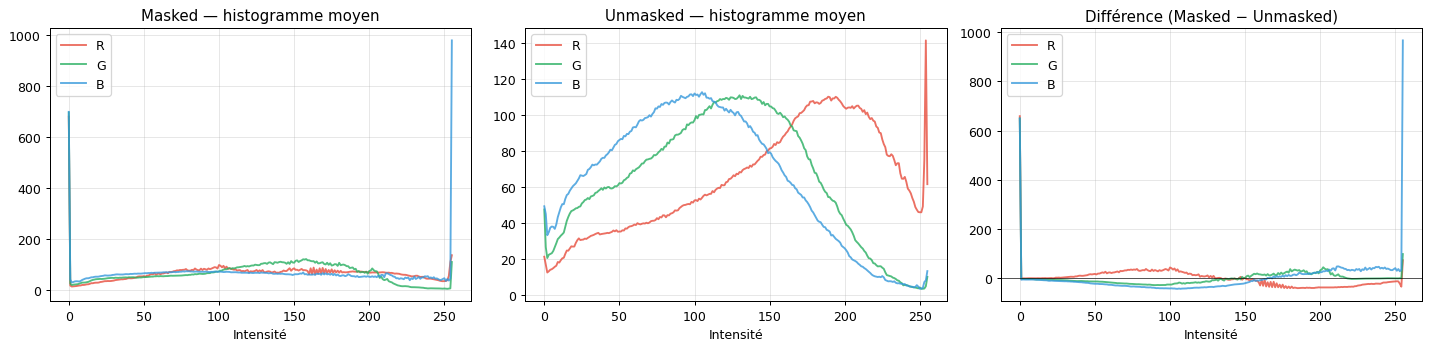

In [13]:
def collect_histogram(part, split, cat, n_images=300):
    d = DATA_DIR / part / split / cat
    if not d.is_dir(): return None
    files = list(d.glob('*.png'))[:n_images]
    if not files: return None
    hist_rgb = np.zeros((3, 256))
    for f in files:
        img = np.array(Image.open(f).convert('RGB'))
        for c in range(3):
            h, _ = np.histogram(img[:,:,c], bins=256, range=(0,256))
            hist_rgb[c] += h
    return hist_rgb / len(files)

hist_m = collect_histogram('part1', 'train', 'masked', 300)
hist_u = collect_histogram('part1', 'train', 'unmasked', 300)

if hist_m is not None and hist_u is not None:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    colors = ['#e74c3c', '#27ae60', '#3498db']
    labels = ['R', 'G', 'B']

    for c in range(3):
        axes[0].plot(hist_m[c], color=colors[c], label=labels[c], alpha=0.8)
        axes[1].plot(hist_u[c], color=colors[c], label=labels[c], alpha=0.8)
    axes[0].set_title('Masked — histogramme moyen'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].set_title('Unmasked — histogramme moyen'); axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[0].set_xlabel('Intensité'); axes[1].set_xlabel('Intensité')

    # Différence (masked - unmasked)
    for c in range(3):
        axes[2].plot(hist_m[c] - hist_u[c], color=colors[c], label=labels[c], alpha=0.8)
    axes[2].axhline(0, color='black', linewidth=0.5)
    axes[2].set_title('Différence (Masked − Unmasked)')
    axes[2].set_xlabel('Intensité'); axes[2].legend(); axes[2].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

## 10. Image moyenne & localisation du masque

En moyennant toutes les images d'une catégorie, on obtient un "visage moyen". La différence entre les deux révèle **où se trouvent typiquement les masques** dans l'image.

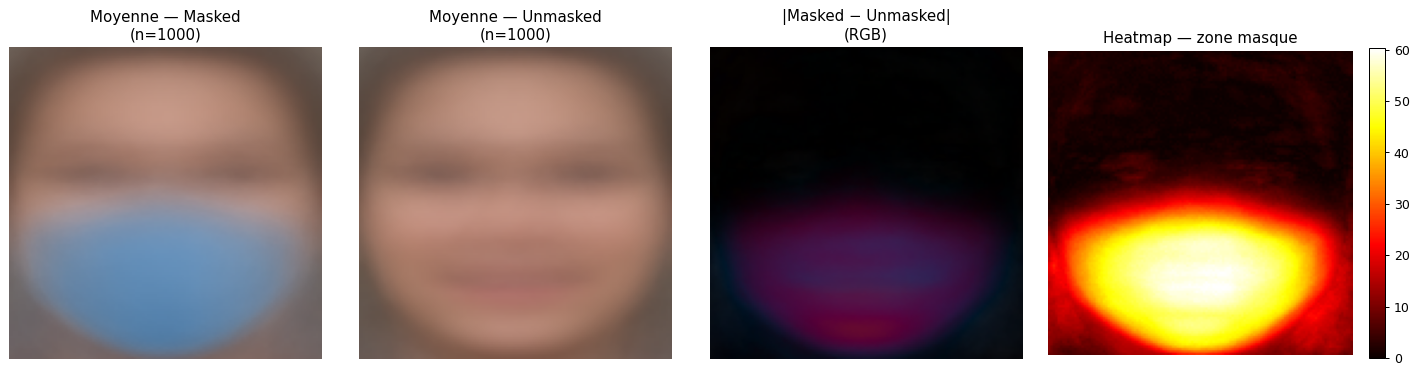


🔥 Intensité moyenne de la différence:
   Moitié haute (yeux/front) : 2.49
   Moitié basse (nez/bouche) : 34.85
   Ratio bas/haut            : 14.01× ✓ masque localisé en bas comme attendu


In [14]:
def compute_average_image(part, split, cat, n_images=1000):
    d = DATA_DIR / part / split / cat
    if not d.is_dir(): return None, 0
    files = list(d.glob('*.png'))
    if not files: return None, 0
    if len(files) > n_images:
        idx = np.random.choice(len(files), size=n_images, replace=False)
        files = [files[i] for i in idx]
    acc = None
    for f in files:
        arr = np.array(Image.open(f).convert('RGB')).astype(np.float32)
        if acc is None: acc = np.zeros_like(arr)
        acc += arr
    return (acc / len(files)).astype(np.uint8), len(files)

avg_m, n_m = compute_average_image('part1', 'train', 'masked', 1000)
avg_u, n_u = compute_average_image('part1', 'train', 'unmasked', 1000)

if avg_m is not None and avg_u is not None:
    diff = np.abs(avg_m.astype(np.int16) - avg_u.astype(np.int16)).astype(np.uint8)
    diff_gray = diff.mean(axis=-1)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(avg_m); axes[0].set_title(f'Moyenne — Masked\n(n={n_m})'); axes[0].axis('off')
    axes[1].imshow(avg_u); axes[1].set_title(f'Moyenne — Unmasked\n(n={n_u})'); axes[1].axis('off')
    axes[2].imshow(diff); axes[2].set_title('|Masked − Unmasked|\n(RGB)'); axes[2].axis('off')
    im = axes[3].imshow(diff_gray, cmap='hot')
    axes[3].set_title('Heatmap — zone masque'); axes[3].axis('off')
    plt.colorbar(im, ax=axes[3], fraction=0.046)
    plt.tight_layout(); plt.show()

    # Diagnostic : la zone "chaude" est-elle bien en bas du visage ?
    h = diff_gray.shape[0]
    top_half   = diff_gray[:h//2].mean()
    bot_half   = diff_gray[h//2:].mean()
    print(f"\n🔥 Intensité moyenne de la différence:")
    print(f"   Moitié haute (yeux/front) : {top_half:.2f}")
    print(f"   Moitié basse (nez/bouche) : {bot_half:.2f}")
    print(f"   Ratio bas/haut            : {bot_half/max(top_half,1e-6):.2f}× "
          f"{'✓ masque localisé en bas comme attendu' if bot_half > top_half else '⚠️ pas de localisation claire'}")

## 11. Comparaison inter-parts

Les 3 parts sont-elles statistiquement comparables ? Si une part a des caractéristiques très différentes, on peut vouloir stratifier l'échantillonnage.

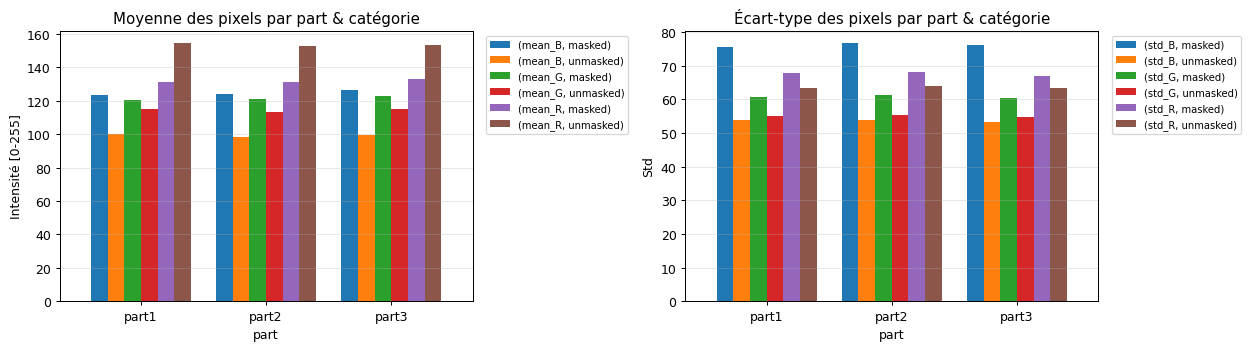

In [15]:
# On utilise df_stats déjà calculé (section 8)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Moyennes par canal × part × catégorie
pivot_mean = df_stats.pivot_table(index='part', columns='category', values=['mean_R','mean_G','mean_B'])
pivot_mean.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('Moyenne des pixels par part & catégorie')
axes[0].set_ylabel('Intensité [0-255]')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

pivot_std = df_stats.pivot_table(index='part', columns='category', values=['std_R','std_G','std_B'])
pivot_std.plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('Écart-type des pixels par part & catégorie')
axes[1].set_ylabel('Std')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

## 12. Synthèse & recommandations

In [ ]:
print("="*70)
print("📋 SYNTHÈSE DE L'EDA")
print("="*70)

total = df_vol['count'].sum()
n_masked = df_vol[df_vol['category']=='masked']['count'].sum()
n_unmasked = df_vol[df_vol['category']=='unmasked']['count'].sum()
n_paired = df_pair['paired'].sum()
n_orphan = df_pair['masked_only'].sum() + df_pair['unmasked_only'].sum()

print(f"\n▸ VOLUMÉTRIE")
print(f"   Total images         : {total:,}")
print(f"   Masked               : {n_masked:,}")
print(f"   Unmasked             : {n_unmasked:,}")
print(f"   Paires utilisables   : {n_paired:,}  ({100*n_paired/max(n_masked,1):.1f}% des masked)")
print(f"   Orphelines           : {n_orphan:,}")

print(f"\n▸ TECHNIQUE")
print(f"   Dimensions           : {dict(sizes)}")
print(f"   Modes couleur        : {dict(modes)}")
print(f"   Taille fichier moy.  : {np.mean(file_sizes_kb):.1f} KB")

print(f"\n▸ RECOMMANDATIONS PIPELINE")
if list(sizes.keys()) == [(128, 128)]:
    print("   ✓ Taille uniforme 128×128 → pas de Resize nécessaire")
else:
    print(f"   ⚠ Dimensions variables → ajouter transforms.Resize(128) dans le pipeline")
if list(modes.keys()) == ['RGB']:
    print("   ✓ Mode RGB uniforme → pas de conversion nécessaire")
else:
    print(f"   ⚠ Modes variables → ajouter .convert('RGB') dans le Dataset")
if n_paired > 0.9 * n_masked:
    print("   ✓ Pairing OK → dataset apparié utilisable directement (L1/L2/perceptual loss)")
elif n_paired == 0:
    print("   ⚠ Aucun pairing → utiliser CycleGAN-style OU générer masques synthétiques")
else:
    print(f"   ⚠ Pairing partiel → filtrer sur les {n_paired:,} paires communes uniquement")

# Pas de val dans part3 ?
has_part3_val = ((df_vol['part']=='part3') & (df_vol['split']=='val')).any()
if not has_part3_val:
    print("   ⚠ Part3 n'a pas de split 'val' → exclure part3 du val OU créer un split custom")

print(f"\n▸ PROCHAINES ÉTAPES")
print("   1. Écrire le Dataset PyTorch (MaskedFaceDataset) basé sur les paires appariées")
print("   2. Créer le pipeline de dégradation HR→LR (downscale pour tâche super-résolution)")
print("   3. Implémenter l'autoencodeur U-Net baseline")
print("   4. Définir les métriques d'évaluation (PSNR, SSIM, LPIPS)")

📋 SYNTHÈSE DE L'EDA

▸ VOLUMÉTRIE
   Total images         : 50,255
   Masked               : 25,415
   Unmasked             : 24,840
   Paires utilisables   : 24,840  (97.7% des masked)
   Orphelines           : 575

▸ TECHNIQUE
   Dimensions           : {(128, 128): 50335}
   Modes couleur        : {'RGB': 50335}
   Taille fichier moy.  : 27.7 KB

▸ RECOMMANDATIONS PIPELINE
   ✓ Taille uniforme 128×128 → pas de Resize nécessaire
   ✓ Mode RGB uniforme → pas de conversion nécessaire
   ✓ Pairing OK → dataset apparié utilisable directement (L1/L2/perceptual loss)
   ⚠ Part3 n'a pas de split 'val' → exclure part3 du val OU créer un split custom

▸ PROCHAINES ÉTAPES
   1. Écrire le Dataset PyTorch (MaskedFaceDataset) basé sur les paires appariées
   2. Créer le pipeline de dégradation HR→LR (downscale pour tâche super-résolution)
   3. Implémenter l'autoencodeur U-Net baseline
   4. Définir les métriques d'évaluation (PSNR, SSIM, LPIPS)


: 